# Differential gene expression across condition combinations

In this tutorial we show how to use `patpy` to run differential expression (DE)
across all pairwise contrasts of a multi-dimensional condition space with a
single function call, using any pertpy statistical model.

`ptc.ConditionComparison.run_once` and `ptc.ConditionComparison.run` handle:
- creating a combined condition label column
- enumerating all (or a selected subset of) observed pairwise contrasts
- running `model.compare_groups()` for each pair
- concatenating results with a `"contrast"` column
- storing a fitted model instance per contrast for pertpy's plotting API

We use the **COMBAT COVID-19 cohort** (PBMC from ~140 donors) as a real-world
example, following the same pseudobulk pipeline as the
[pertpy DE tutorial](https://pertpy.readthedocs.io/en/stable/tutorials/notebooks/differential_gene_expression.html).

## Install

```bash
pip install patpy pertpy pydeseq2
# For EdgeR (requires R):
pip install rpy2
# In R: BiocManager::install("edgeR")
```

## Import packages

In [1]:
import pertpy as pt
import scanpy as sc
import pandas as pd
import numpy as np
import anndata as ad
import scipy.sparse as sp
import matplotlib.pyplot as plt
import warnings

import patpy
import patpy.tl.condition_comparison as ptc

warnings.filterwarnings("ignore")
patpy.__version__

/lustre/groups/ml01/workspace/lucas.arnoldt/cellink_patpy/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


'0.12.1'

## Load the COMBAT dataset

The dataset contains 836k cells x 20,807 genes from ~140 PBMC donors spanning
healthy volunteers (HV) and COVID-19 patients at various severity levels.

In [2]:
ADATA_PATH = "/home/icb/lucas.arnoldt/workspace/projects/patpy/COMBAT-CITESeq-DATA.h5ad"
adata = sc.read_h5ad(ADATA_PATH)
adata

AnnData object with n_obs × n_vars = 836148 × 20807
    obs: 'Annotation_cluster_id', 'Annotation_cluster_name', 'Annotation_minor_subset', 'Annotation_major_subset', 'Annotation_cell_type', 'GEX_region', 'QC_ngenes', 'QC_total_UMI', 'QC_pct_mitochondrial', 'QC_scrub_doublet_scores', 'TCR_chain_composition', 'TCR_clone_ID', 'TCR_clone_count', 'TCR_clone_proportion', 'TCR_contains_unproductive', 'TCR_doublet', 'TCR_chain_TRA', 'TCR_v_gene_TRA', 'TCR_d_gene_TRA', 'TCR_j_gene_TRA', 'TCR_c_gene_TRA', 'TCR_productive_TRA', 'TCR_cdr3_TRA', 'TCR_umis_TRA', 'TCR_chain_TRA2', 'TCR_v_gene_TRA2', 'TCR_d_gene_TRA2', 'TCR_j_gene_TRA2', 'TCR_c_gene_TRA2', 'TCR_productive_TRA2', 'TCR_cdr3_TRA2', 'TCR_umis_TRA2', 'TCR_chain_TRB', 'TCR_v_gene_TRB', 'TCR_d_gene_TRB', 'TCR_j_gene_TRB', 'TCR_c_gene_TRB', 'TCR_productive_TRB', 'TCR_chain_TRB2', 'TCR_v_gene_TRB2', 'TCR_d_gene_TRB2', 'TCR_j_gene_TRB2', 'TCR_c_gene_TRB2', 'TCR_productive_TRB2', 'TCR_cdr3_TRB2', 'TCR_umis_TRB2', 'BCR_umis_HC', 'BCR_contig_qc_H

## Set column names

In [3]:
sample_id_col = "scRNASeq_sample_ID"       # per-donor identifier
cell_type_key = "Annotation_major_subset"  # broad cell type labels
source_col    = "Source"                   # COVID_SEV / HV
sex_col       = "Sex"                      # Male / Female

## Quality control

Remove donors with fewer than 100 cells.

In [4]:
adata = patpy.pp.filter_small_samples(
    adata, sample_key=sample_id_col, sample_size_threshold=100
)
print(f"{adata.obs[sample_id_col].nunique()} donors after QC filtering")
adata.layers["raw"] = adata.layers["raw"].todense()

2 samples removed: G05092-Ja005E-PBCa, S00030-Ja003E-PBCa
138 donors after QC filtering


## Subset to a manageable cohort

We keep only **COVID-19 patients and healthy volunteers** and sample up to
**20 donors per source** so the analysis finishes quickly.
Remove this cell to run on the full dataset.

In [5]:
# Restrict to Covid and HV sources only
adata = adata[adata.obs[source_col].isin(["COVID_SEV", "HV"])].copy()

# Sample up to 20 donors per source so both groups are always present
rng = np.random.default_rng(42)
keep = []
for source, grp in adata.obs.groupby(source_col):
    donors = grp[sample_id_col].unique()
    sampled = rng.choice(donors, size=min(20, len(donors)), replace=False)
    keep.extend(sampled)

adata = adata[adata.obs[sample_id_col].isin(keep)].copy()

print(f"{adata.n_obs:,} cells | {adata.obs[sample_id_col].nunique()} donors")
adata.obs[[sample_id_col, source_col]].drop_duplicates()[source_col].value_counts()

214,842 cells | 30 donors


Source
COVID_SEV    20
HV           10
Name: count, dtype: int64

## Inspect metadata

In [6]:
donor_meta = adata.obs[[sample_id_col, sex_col, source_col]].drop_duplicates()
print(donor_meta[sex_col].value_counts().sort_index().to_string())
print(donor_meta[source_col].value_counts().sort_index().to_string())

Sex
0    14
1    16
Source
HV           10
COVID_SEV    20


## Create pseudobulk profiles

DE models require integer counts aggregated at the donor level.
We use `patpy.tl.Pseudobulk` for aggregation and `patpy.pp.extract_metadata`
to build the donor-level obs DataFrame.

In [7]:
pb = patpy.tl.Pseudobulk(
    sample_key=sample_id_col,
    cell_group_key=cell_type_key,
    layer="raw",
)
pb.prepare_anndata(adata)
pb.calculate_distance_matrix()
print(f"sample_representation shape: {pb.sample_representation.shape}")
print(f"donors: {len(pb.samples)}")

sample_representation shape: (30, 20807)
donors: 30


In [8]:
# Build donor-level obs using patpy.pp.extract_metadata
donor_obs = patpy.pp.extract_metadata(
    adata, sample_key=sample_id_col, columns=[source_col, sex_col]
)
donor_obs

,Source,Sex
scRNASeq_sample_ID,,
S00056-Ja003E-PBCa,COVID_SEV,0
H00067-Ha001E-PBGa,HV,0
S00028-Ja001E-PBCa,COVID_SEV,0
S00033-Ja001E-PBCa,COVID_SEV,1
H00054-Ha001E-PBGa,HV,1
S00078-Ja003E-PBCa,COVID_SEV,0
S00042-Ja003E-PBCa,COVID_SEV,0
H00085-Ha001E-PBGa,HV,0
S00056-Ja005E-PBCa,COVID_SEV,0


In [9]:
# Aggregate raw counts per donor (sum) for DE models
raw = adata.layers["raw"]
X_counts = np.zeros((len(pb.samples), adata.n_vars), dtype=np.float32)
for i, sample in enumerate(pb.samples):
    mask = (adata.obs[sample_id_col] == sample).values
    X_counts[i] = np.asarray(raw[mask, :].sum(axis=0)).flatten()

pdata = ad.AnnData(X=X_counts, obs=donor_obs, var=adata.var)
pdata.layers["counts"] = pdata.X.copy()
pdata

AnnData object with n_obs × n_vars = 30 × 20807
    obs: 'Source', 'Sex'
    var: 'gene_ids', 'feature_types'
    layers: 'counts'

## Explore axes of variation

Before fitting any DE model it is useful to understand which covariates
drive variance in the pseudobulk profiles. We run PCA and use
`patpy.tl.associate_pcs_with_covariates` to test each PC against each
clinical variable, then visualise with `patpy.pl.pc_covariate_heatmap`.

This guides the choice of design formula and which contrasts are worth testing.

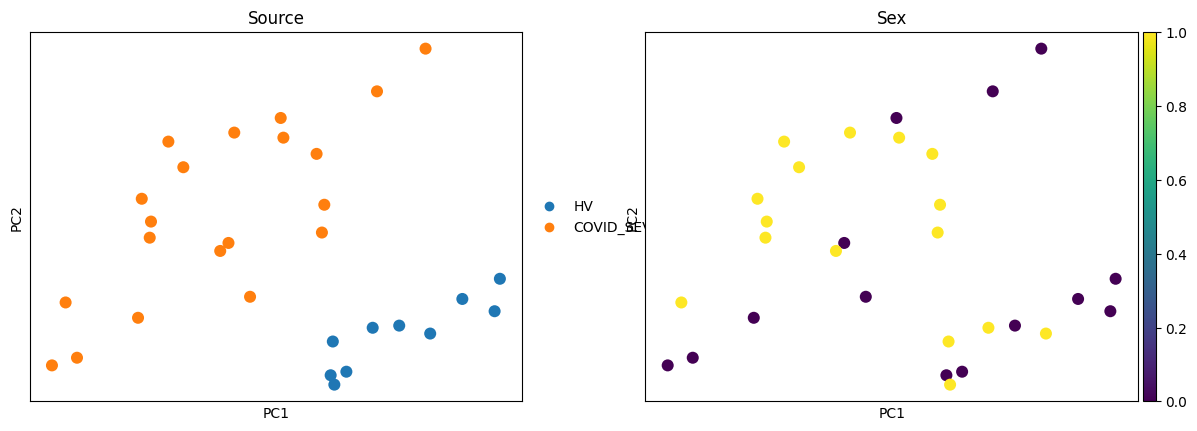

In [10]:
pdata_pca = pdata.copy()
sc.pp.normalize_total(pdata_pca, target_sum=1e4)
sc.pp.log1p(pdata_pca)
sc.pp.scale(pdata_pca, max_value=10)
sc.pp.pca(pdata_pca)

# Copy PCA embedding back to pdata for downstream association test
pdata.obsm["X_pca"] = pdata_pca.obsm["X_pca"]

sc.pl.pca(pdata_pca, color=[source_col, sex_col], ncols=2, size=300)

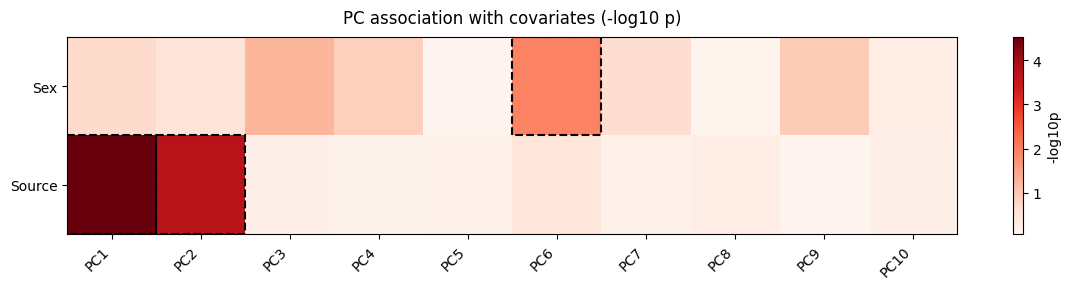

In [11]:
# Test which PCs are driven by each clinical covariate
assoc = patpy.tl.associate_pcs_with_covariates(
    pdata,
    covariates=[source_col, sex_col],
    n_pcs=10,
)

patpy.pl.pc_covariate_heatmap(assoc)

## Inspect the condition space

`ptc.build_condition_combinations` lists every *observed* combination of
condition axes and `ptc.build_all_pairwise_contrasts` enumerates all pairs.
This is a quick sanity check before launching any model fits.

In [12]:
condition_cols = [source_col, sex_col]

combos = ptc.build_condition_combinations(pdata, condition_cols)
print(f"{len(combos)} observed condition combinations:")
combos

4 observed condition combinations:


,Source,Sex,label
0,COVID_SEV,0,COVID_SEV_0
1,HV,0,HV_0
2,COVID_SEV,1,COVID_SEV_1
3,HV,1,HV_1


In [13]:
contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)
print(f"{len(contrasts)} pairwise contrasts:")
for c in contrasts:
    print(f"  {c['label']}")

6 pairwise contrasts:
  COVID_SEV_0_vs_HV_0
  COVID_SEV_0_vs_COVID_SEV_1
  COVID_SEV_0_vs_HV_1
  HV_0_vs_COVID_SEV_1
  HV_0_vs_HV_1
  COVID_SEV_1_vs_HV_1


## Differential expression — PyDESeq2

`run_once` returns a `(results_df, models)` tuple. `results_df` is the tidy
DE table; `models` is a dict mapping each contrast label to a model instance
so you can call any pertpy plotting method directly.

In [14]:
res_deseq2, models_deseq2 = ptc.ConditionComparison.run_once(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
    layer="counts",
)

print(f"{len(res_deseq2):,} DE results across {res_deseq2['contrast'].nunique()} contrasts")
print("Available contrasts:", list(models_deseq2))
res_deseq2.head()

Fitting size factors...
... done in 0.07 seconds.



Using None as control genes, passed at DeseqDataSet initialization


Fitting dispersions...
... done in 12.75 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 17.78 seconds.

Fitting LFCs...
... done in 9.54 seconds.

Calculating cook's distance...
... done in 0.13 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.20 seconds.

Fitting LFCs...
... done in 0.15 seconds.

Running Wald tests...
... done in 114.59 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.66 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 17.23 seconds.

Fitting LFCs...
... done in 10.74 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 161 outlier genes.

Fitting dispersions...
... done in 0.17 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 110.15 seconds.



...

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 11.69 seconds.

Fitting dispersion trend curve...
... done in 0.38 seconds.

Fitting MAP dispersions...
... done in 15.44 seconds.

Fitting LFCs...
... done in 8.55 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 108.65 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218141  3.429173 -0.063613  0.949278   
NOC2L             1457.437279        0.008025  0.072268  0.111044  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898300  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114997 -1.119207  0.263052   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787391  0.073874   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949 

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 12.90 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

Fitting MAP dispersions...
... done in 16.83 seconds.

Fitting LFCs...
... done in 10.09 seconds.

Calculating cook's distance...
... done in 0.19 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 108.05 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

,variable,baseMean,log_fc,lfcSE,stat,p_value,adj_p_value,contrast
0,ZNF230,138.987101,-1.575528,0.147200,-10.703326,9.818907e-27,1.443870e-22,COVID_SEV_0_vs_HV_0
1,TNFSF14,328.762813,-1.947968,0.184911,-10.534641,5.981085e-26,4.397593e-22,COVID_SEV_0_vs_HV_0
2,CDCA5,236.643742,3.006126,0.309581,9.710300,2.725329e-22,1.335865e-18,COVID_SEV_0_vs_HV_0
3,METTL18,399.540801,-1.138663,0.118743,-9.589296,8.868817e-22,3.260399e-18,COVID_SEV_0_vs_HV_0
4,ID3,546.295056,-2.568833,0.269282,-9.539555,1.434469e-21,4.218774e-18,COVID_SEV_0_vs_HV_0


## Differential expression — EdgeR

Switch to EdgeR by changing a single argument — everything else is identical.
EdgeR requires R with the `edgeR` Bioconductor package installed.

In [15]:
res_edger, models_edger = ptc.ConditionComparison.run_once(
    pt.tl.EdgeR,
    pdata,
    condition_cols=condition_cols,
    layer="counts",
)

print(f"{len(res_edger):,} DE results across {res_edger['contrast'].nunique()} contrasts")
res_edger.head()

• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
• Calculating NormFactors
• Estimating Dispersions
• Fitting linear model
124,842 DE results across 6 contrasts


,variable,log_fc,logCPM,F,p_value,adj_p_value,contrast
0,ZNF230,-1.597952,1.332414,118.189063,9.179426e-09,0.00010,COVID_SEV_0_vs_HV_0
1,TNFSF14,-1.966533,2.558231,117.450233,9.567627e-09,0.00010,COVID_SEV_0_vs_HV_0
2,KIRREL3,-3.524165,-2.683243,68.893660,1.792087e-08,0.00011,COVID_SEV_0_vs_HV_0
3,S1PR1,-1.521756,5.490698,102.687991,2.445235e-08,0.00011,COVID_SEV_0_vs_HV_0
4,ID3,-2.589889,3.292700,101.491364,2.654054e-08,0.00011,COVID_SEV_0_vs_HV_0


## Reuse settings with `ConditionComparison`

`ConditionComparison` stores the model class and default kwargs so you can
run the same setup across multiple condition axes without repeating yourself.
After each `run()` call, model instances are stored in `cc.models_` and
accessible via `cc.get_model(contrast_label)` for pertpy's plotting API.

In [16]:
cc = ptc.ConditionComparison(pt.tl.PyDESeq2, layer="counts")
cc

ConditionComparison(PyDESeq2, layer='counts')

In [17]:
# All pairwise combinations of Source x Sex
res_source_sex = cc.run(pdata, condition_cols=[source_col, sex_col])

# Source alone — the primary biological axis
res_source = cc.run(pdata, condition_cols=[source_col])

print("Source x Sex contrasts:", res_source_sex["contrast"].unique().tolist())
print("Source-only contrasts: ", res_source["contrast"].unique().tolist())
print("All stored models:", list(cc.models_))
cc  # repr shows model count after run

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.44 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 16.38 seconds.

Fitting LFCs...
... done in 9.48 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...
... done in 109.29 seconds.

Fitting size factors...
... done in 0.01 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting dispersions...
... done in 12.90 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 17.35 seconds.

Fitting LFCs...
... done in 10.10 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 161 outlier genes.

Fitting dispersions...
... done in 0.15 seconds.

Fitting MAP dispersions...
... done in 0.18 seconds.

Fitting LFCs...
... done in 0.14 seconds.

Running Wald tests...
... done in 109.23 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.475906       -1.105399  1.447395 -0.763716  0.445036   
NOC2L             1105.555690        0.029393  0.085567  0.343515  0.731211   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   12564.791412        0.146508  0.145149  1.009365  0.312800   
AB_CD224        204842.505419       -0.100986  0.143275 -0.704845  0.480907   
AB_c_Met         36280.451090        0.092051  0.134713  0.683312  0.494409   
AB_CD258_LIGHT   25655.855243        0.153377  0.158993  0.964678  0.334706   
AB_DR3_TRAMP     44420.734956        0.089646  0.126683  0.707636 

...

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.74 seconds.

Fitting dispersion trend curve...
... done in 0.39 seconds.

Fitting MAP dispersions...
... done in 18.04 seconds.

Fitting LFCs...
... done in 9.28 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.16 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 109.25 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

Fitting size factors...
... done in 0.02 seconds.

Fitting dispersions...
... done in 13.70 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 18.37 seconds.

Fitting LFCs...
... done in 9.66 seconds.

Calculating cook's distance...
... done in 0.03 seconds.

Replacing 252 outlier genes.

Fitting dispersions...
... done in 0.27 seconds.

Fitting MAP dispersions...
... done in 0.30 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Running Wald tests...
... done in 108.44 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.396043        1.248338  1.305570  0.956163  0.338990   
NOC2L             1212.810770        0.067816  0.061259  1.107030  0.268281   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   14104.676718       -0.039824  0.107165 -0.371613  0.710181   
AB_CD224        209277.179155        0.409534  0.120222  3.406467  0.000658   
AB_c_Met         40707.871349       -0.036795  0.098071 -0.375191  0.707518   
AB_CD258_LIGHT   27915.251432        0.097523  0.116619  0.836254  0.403012   
AB_DR3_TRAMP     50528.479383       -0.093938  0.091834 -1.022908 

ConditionComparison(PyDESeq2, layer='counts') [7 model(s): ['COVID_SEV_0_vs_HV_0', 'COVID_SEV_0_vs_COVID_SEV_1', 'COVID_SEV_0_vs_HV_1', 'HV_0_vs_COVID_SEV_1', 'HV_0_vs_HV_1', 'COVID_SEV_1_vs_HV_1', 'COVID_SEV_vs_HV']]

## Restrict to biologically motivated contrasts

Pass `subset_contrasts` to run only the comparisons you care about — here,
only contrasts that involve the HV (healthy volunteer) reference group.

In [18]:
all_contrasts = ptc.build_all_pairwise_contrasts(pdata, condition_cols)

vs_hv = [c for c in all_contrasts if "HV" in c["group"] or "HV" in c["baseline"]]
print("Contrasts vs HV:", [c["label"] for c in vs_hv])

res_vs_hv, models_vs_hv = ptc.ConditionComparison.run_once(
    pt.tl.PyDESeq2,
    pdata,
    condition_cols=condition_cols,
    layer="counts",
    subset_contrasts=vs_hv,
)
res_vs_hv["contrast"].unique()

Contrasts vs HV: ['COVID_SEV_0_vs_HV_0', 'COVID_SEV_0_vs_HV_1', 'HV_0_vs_COVID_SEV_1', 'HV_0_vs_HV_1', 'COVID_SEV_1_vs_HV_1']
Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.45 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

Fitting MAP dispersions...
... done in 17.85 seconds.

Fitting LFCs...
... done in 9.76 seconds.

Calculating cook's distance...
... done in 0.02 seconds.

Replacing 162 outlier genes.

Fitting dispersions...
... done in 0.16 seconds.

Fitting MAP dispersions...
... done in 0.19 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Running Wald tests...
... done in 109.34 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.257261        0.638596  2.704208  0.236149  0.813317   
NOC2L             1301.177247        0.094372  0.111198  0.848677  0.396061   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15319.067933        0.120656  0.180509  0.668418  0.503866   
AB_CD224        205047.129847        0.497971  0.158971  3.132462  0.001733   
AB_c_Met         43838.260224        0.078896  0.163130  0.483640  0.628642   
AB_CD258_LIGHT   30073.626348        0.274918  0.196365  1.400034  0.161503   
AB_DR3_TRAMP     54924.487941       -0.001373  0.150129 -0.009143 

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.10 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

Fitting MAP dispersions...
... done in 15.64 seconds.

Fitting LFCs...
... done in 9.04 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 123 outlier genes.

Fitting dispersions...
... done in 0.13 seconds.

Fitting MAP dispersions...
... done in 0.15 seconds.

Fitting LFCs...
... done in 0.12 seconds.

Running Wald tests...
... done in 108.87 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.304920        0.413179  2.795188  0.147818  0.882486   
NOC2L             1275.680812        0.094984  0.141383  0.671824  0.501696   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   15661.234430       -0.046817  0.227499 -0.205790  0.836955   
AB_CD224        220335.647664        0.167137  0.180218  0.927415  0.353711   
AB_c_Met         44364.190769       -0.055211  0.201932 -0.273415  0.784534   
AB_CD258_LIGHT   31169.337939        0.077529  0.240061  0.322956  0.746729   
AB_DR3_TRAMP     54636.606110       -0.082354  0.184598 -0.446130 

...

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 11.60 seconds.

Fitting dispersion trend curve...
... done in 0.37 seconds.

Fitting MAP dispersions...
... done in 15.28 seconds.

Fitting LFCs...
... done in 8.79 seconds.

Calculating cook's distance...
... done in 0.01 seconds.

Replacing 0 outlier genes.

Running Wald tests...
... done in 108.29 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.161094       -0.218141  3.429173 -0.063613  0.949278   
NOC2L             1457.437279        0.008025  0.072268  0.111044  0.911581   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   17811.995772       -0.162549  0.120624 -1.347573  0.177796   
AB_CD224        212810.362686       -0.324465  0.170924 -1.898300  0.057657   
AB_c_Met         51331.924318       -0.128705  0.114997 -1.119207  0.263052   
AB_CD258_LIGHT   33068.168373       -0.192380  0.107632 -1.787391  0.073874   
AB_DR3_TRAMP     65395.739182       -0.075470  0.112482 -0.670949 

Fitting size factors...
... done in 0.01 seconds.

Fitting dispersions...
... done in 12.59 seconds.

Fitting dispersion trend curve...
... done in 0.36 seconds.

Fitting MAP dispersions...
... done in 16.30 seconds.

Fitting LFCs...
... done in 9.42 seconds.

Calculating cook's distance...
... done in 0.04 seconds.

Replacing 124 outlier genes.

Fitting dispersions...
... done in 0.12 seconds.

Fitting MAP dispersions...
... done in 0.16 seconds.

Fitting LFCs...
... done in 0.13 seconds.

Running Wald tests...
... done in 108.76 seconds.



Log2 fold change & Wald test p-value, contrast vector: [ 0. -1.]
                     baseMean  log2FoldChange     lfcSE      stat    pvalue  \
OR4F5                0.000000             NaN       NaN       NaN       NaN   
OR4F29               0.000000             NaN       NaN       NaN       NaN   
OR4F16               0.000000             NaN       NaN       NaN       NaN   
SAMD11               0.501578        1.498871  1.903771  0.787317  0.431096   
NOC2L             1140.414076        0.052733  0.084487  0.624154  0.532527   
...                       ...             ...       ...       ...       ...   
AB_Podocalyxin   13100.698970       -0.201278  0.120307 -1.673042  0.094319   
AB_CD224        211821.629447        0.255880  0.180603  1.416811  0.156538   
AB_c_Met         38107.199532       -0.156263  0.121557 -1.285508  0.198615   
AB_CD258_LIGHT   26119.231594       -0.084049  0.129068 -0.651197  0.514919   
AB_DR3_TRAMP     46912.388948       -0.181463  0.121083 -1.498663 

array(['COVID_SEV_0_vs_HV_0', 'COVID_SEV_0_vs_HV_1',
       'HV_0_vs_COVID_SEV_1', 'HV_0_vs_HV_1', 'COVID_SEV_1_vs_HV_1'],
      dtype=object)

## Inspect and visualise results

The tidy results DataFrame can be filtered and plotted directly.
We use pertpy's built-in plotting methods via the stored model instances —
either through `cc.plot()` (convenience wrapper) or `cc.get_model()` for
full control.

In [19]:
# Number of significant genes per contrast (FDR < 0.05)
sig = res_deseq2[res_deseq2["adj_p_value"] < 0.05]
n_sig = (
    sig.groupby("contrast")["variable"]
    .count()
    .rename("n_sig_genes")
    .sort_values(ascending=False)
)
print(n_sig.to_string())

contrast
HV_0_vs_COVID_SEV_1           6316
COVID_SEV_1_vs_HV_1           4135
COVID_SEV_0_vs_HV_0           3641
COVID_SEV_0_vs_HV_1           2377
COVID_SEV_0_vs_COVID_SEV_1     231
HV_0_vs_HV_1                    70


NaNs encountered, dropping rows with NaNs
0s encountered for p value, replacing with 1e-323


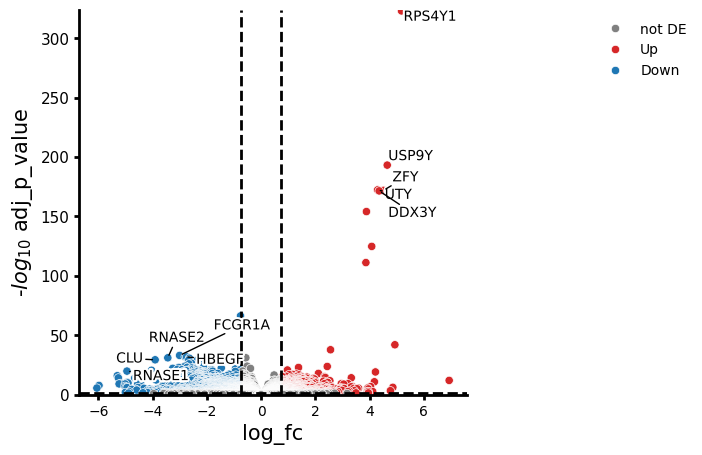

In [20]:
# Volcano plot for the contrast with the most DE genes
# cc.plot() retrieves the model instance, filters the DataFrame to this
# contrast, and calls pertpy's plot_volcano — all in one line.
top_contrast = n_sig.index[0]
cc.plot("plot_volcano", contrast=top_contrast, results_df=res_deseq2)

NaNs encountered, dropping rows with NaNs
0s encountered for p value, replacing with 1e-323


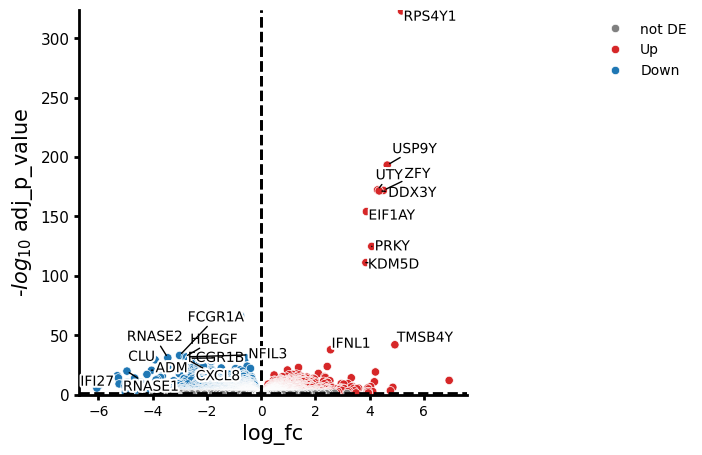

In [21]:
# For full control over plot kwargs, retrieve the model instance directly
model = cc.get_model(top_contrast)
model.plot_volcano(
    res_deseq2[res_deseq2["contrast"] == top_contrast],
    log2fc_thresh=0,
    to_label=10,
)

In [23]:
# Top DE genes across all contrasts (FDR < 0.05, ranked by |log2FC|)
(
    sig
    .assign(abs_lfc=sig["log_fc"].abs())
    .sort_values("abs_lfc", ascending=False)
    [["variable", "log_fc", "adj_p_value", "contrast"]]
    .drop_duplicates(subset="variable")
    .head(20)
)

,variable,log_fc,adj_p_value,contrast
62669,NLGN4Y,6.938495,9.139796e-13,HV_0_vs_COVID_SEV_1
104790,IGHV7-4-1,6.479591,2.700344e-05,COVID_SEV_1_vs_HV_1
41625,PPP1R2C,-6.109462,5.559397e-16,COVID_SEV_0_vs_HV_1
63686,IGHV2-70D,-6.057814,2.458839e-06,HV_0_vs_COVID_SEV_1
63105,MT1M,-5.979759,1.507049e-08,HV_0_vs_COVID_SEV_1
42879,RPS4Y2,5.934048,8.287526e-03,COVID_SEV_0_vs_HV_1
41889,IGLV1-36,-5.910407,1.064951e-05,COVID_SEV_0_vs_HV_1
105075,NEBL,-5.901076,1.273689e-04,COVID_SEV_1_vs_HV_1
42196,CH25H,5.745514,3.765922e-04,COVID_SEV_0_vs_HV_1
41754,SCARA5,-5.676529,2.323386e-07,COVID_SEV_0_vs_HV_1
